## Plot Wflow static maps

**HydroMT** provides a simple interface to model schematization from which we can make beautiful plots:

- Raster layers are saved to the model `staticmaps` component as a  `xarray.Dataset`
- Vector layers are saved to the model `staticgeoms` component as a `geopandas.GeoDataFrame`. Note that in case of Wflow these are not used by the model engine, but only for analysis and visualization purposes.

We use the [cartopy](https://scitools.org.uk/cartopy/docs/latest/) package to plot maps. This packages provides a simple interface to plot geographic data and add background satellite imagery.

### Load dependencies

In [1]:
import xarray as xr
import numpy as np
import hydromt
from hydromt_wflow import WflowSbmModel

In [2]:
# Plotting dependencies
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

### Read the model

In [3]:
root = "wflow_piave_subbasin"
model = WflowSbmModel(root, mode="r")

2026-03-09 14:13:52,738 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 14:13:52,738 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 14:13:52,788 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 14:13:52,789 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_subbasin/wflow_sbm.toml.


### Plot model schematization base maps

Here we plot the model basemaps (topography map with rivers, reservoirs, glaciers and gauges geometries). 

In [4]:
# read and mask the model elevation
da = model.staticmaps.data["land_elevation"].raster.mask_nodata()
da.attrs.update(long_name="elevation", units="m")
# read/derive river geometries
gdf_riv = model.rivers
# read/derive model basin boundary
gdf_bas = model.basins

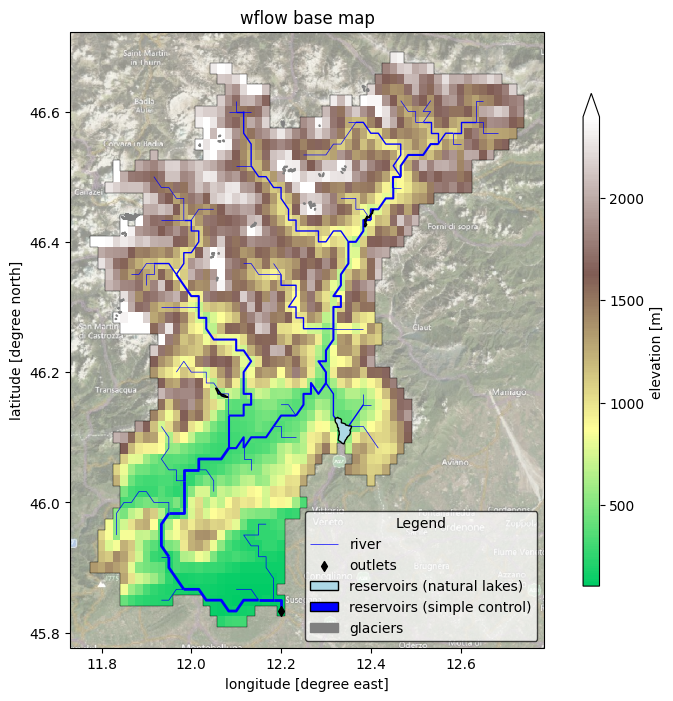

In [5]:
# we assume the model maps are in the geographic CRS EPSG:4326
proj = ccrs.PlateCarree()
# adjust zoomlevel and figure size to your basis size & aspect
zoom_level = 10
figsize = (10, 8)
shaded = False  # shaded elevation (looks nicer with more pixels (e.g.: larger basins))!

# initialize image with geoaxes
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(projection=proj)
bbox = da.raster.box.to_crs(3857).buffer(5e3).to_crs(da.raster.crs).total_bounds
extent = np.array(bbox)[[0, 2, 1, 3]]
ax.set_extent(extent, crs=proj)

# add sat background image
ax.add_image(cimgt.QuadtreeTiles(), zoom_level, alpha=0.5)

## plot elevation\
# create nice colormap
vmin, vmax = da.quantile([0.0, 0.98]).compute()
c_dem = plt.cm.terrain(np.linspace(0.25, 1, 256))
cmap = colors.LinearSegmentedColormap.from_list("dem", c_dem)
norm = colors.Normalize(vmin=vmin, vmax=vmax)
kwargs = dict(cmap=cmap, norm=norm)
# plot 'normal' elevation
da.plot(
    transform=proj, ax=ax, zorder=1, cbar_kwargs=dict(aspect=30, shrink=0.8), **kwargs
)
# plot elevation with shades
if shaded:
    ls = colors.LightSource(azdeg=315, altdeg=45)
    dx, dy = da.raster.res
    _rgb = ls.shade(
        da.fillna(0).values,
        norm=kwargs["norm"],
        cmap=kwargs["cmap"],
        blend_mode="soft",
        dx=dx,
        dy=dy,
        vert_exag=200,
    )
    rgb = xr.DataArray(dims=("y", "x", "rgb"), data=_rgb, coords=da.raster.coords)
    rgb = xr.where(np.isnan(da), np.nan, rgb)
    rgb.plot.imshow(transform=proj, ax=ax, zorder=2)

# plot rivers with increasing width with stream order
gdf_riv.plot(
    ax=ax, linewidth=gdf_riv["strord"] / 2, color="blue", zorder=3, label="river"
)
# plot the basin boundary
gdf_bas.boundary.plot(ax=ax, color="k", linewidth=0.3)
# plot various vector layers if present
if "outlets" in model.geoms.data:
    model.geoms.data["outlets"].plot(
        ax=ax, marker="d", markersize=25, facecolor="k", zorder=5, label="outlets"
    )
patches = []  # manual patches for legend, see https://github.com/geopandas/geopandas/issues/660
if "meta_reservoirs_no_control" in model.geoms.data:
    kwargs = dict(facecolor="lightblue", edgecolor="black", linewidth=1, label="reservoirs (natural lakes)")
    model.geoms.data["meta_reservoirs_no_control"].plot(ax=ax, zorder=4, **kwargs)
    patches.append(mpatches.Patch(**kwargs))
if "meta_reservoirs_simple_control" in model.geoms.data:
    kwargs = dict(facecolor="blue", edgecolor="black", linewidth=1, label="reservoirs (simple control)")
    model.geoms.data["meta_reservoirs_simple_control"].plot(ax=ax, zorder=4, **kwargs)
    patches.append(mpatches.Patch(**kwargs))
if "glaciers" in model.geoms.data:
    kwargs = dict(facecolor="grey", edgecolor="grey", linewidth=1, label="glaciers")
    model.geoms.data["glaciers"].plot(ax=ax, zorder=4, **kwargs)
    patches.append(mpatches.Patch(**kwargs))

ax.xaxis.set_visible(True)
ax.yaxis.set_visible(True)
ax.set_ylabel(f"latitude [degree north]")
ax.set_xlabel(f"longitude [degree east]")
_ = ax.set_title(f"wflow base map")
legend = ax.legend(
    handles=[*ax.get_legend_handles_labels()[0], *patches],
    title="Legend",
    loc="lower right",
    frameon=True,
    framealpha=0.7,
    edgecolor="k",
    facecolor="white",
)

# save figure
# NOTE create figs folder in model root if it does not exist
# fn_out = join(mod.root, "figs", "basemap.png")
# plt.savefig(fn_out, dpi=225, bbox_inches="tight")